# Ride Demand Prediction — Data Exploration & XGBoost Model

## Overview
This notebook forms the primary data pipeline for predicting hourly ride demand
across Manhattan taxi zones. We are loading, cleaning and aggregate 12 months of NYC Yellow
Taxi trip records (2024), engineer time-series features, and train an XGBoost
regression model as our first and primary demand prediction model.

**Target Variable:** `demand` — number of rides per zone per hour  
**Data Source:** NYC Taxi & Limousine Commission, 2024 Yellow Taxi Trip Records  
**Geographic Scope:** Manhattan only (69 pickup zones)

## 1. Library Imports

We begin by importing the necessary libraries for data manipulation, visualisation,
and model training. XGBoost is a gradient boosting framework widely adopted in
industry and academic literature for structured/tabular data due to its strong
predictive performance and computational efficiency (Chen & Guestrin, 2016).

In [58]:
import sys, os
sys.path.append(os.path.abspath('../ride_demand')) # Accessing Kimon's dataset.py module

import dataset                          # Shared data loader (Kimon's module)
import pandas as pd                     # Data manipulation and aggregation
import numpy as np                      # Numerical operations
import matplotlib.pyplot as plt         # Plotting and visualisation
import seaborn as sns                   # Enhanced statistical visualisation

from xgboost import XGBRegressor        # Primary model — install with: pip install xgboost
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## 2. Data Loading

We load the NYC Yellow Taxi trip records for 2024 using the shared `dataset.py`
module. The full 12-month dataset is used for final model training and evaluation.

Each row in the raw dataset represents a **single taxi trip**, containing
pickup/dropoff timestamps, location IDs, fare amounts, and other trip-level
attributes.

**Note:** The raw dataset contains approximately 41 million rows across all NYC
boroughs for 2024. Loading all 12 months may take several minutes.

In [59]:
# Load all 12 months of 2024 NYC Yellow Taxi data
# Files expected at: ../../data/nyc_taxi_2024-XX.csv
# During development, use month_end=2 to speed up iteration
df = dataset.raw(month_start=1, month_end=12)

# Sanity check: confirm data loaded correctly
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (41169720, 19)

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

First 3 rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0


## 3. Geographic Filtering — Manhattan Only

The NYC TLC dataset covers all five boroughs. Since our ride-hailing platform is
launching exclusively in **Manhattan**, we use the official TLC Taxi Zone Lookup
table to identify the 69 Manhattan pickup zones.

Filtering to a single borough:
- Reduces noise from other geographic areas
- Ensures predictions are relevant to the operational scope of the business
- Significantly reduces dataset size, improving model training speed

In [60]:
# Load the TLC Taxi Zone Lookup table
# This maps LocationID -> Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island)
zones = pd.read_csv("../../data/taxi_zone_lookup.csv")

print(zones.head())
print("\nBoroughs available:", zones["Borough"].unique())

# Extract only Manhattan zone IDs (69 zones)
manhattan_ids = zones[zones["Borough"] == "Manhattan"]["LocationID"].tolist()
print(f"\nNumber of Manhattan zones: {len(manhattan_ids)}")

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone

Boroughs available: ['EWR' 'Queens' 'Bronx' 'Manhattan' 'Staten Island' 'Brooklyn' 'Unknown'
 nan]

Number of Manhattan zones: 69


## 4. Data Cleaning

Real-world datasets invariably contain erroneous or missing records. We apply the
following cleaning steps to ensure data quality before modelling:

- **Manhattan filter**: Keep only pickups originating within Manhattan's 69 zones
- **Invalid fares**: Remove trips with zero or negative fare amounts — these represent
  data entry errors or non-standard transactions (e.g. cancelled rides)
- **Invalid distances**: Exclude trips with zero or negative trip distances
- **Temporal anomalies**: Remove trips where pickup time occurs *after* dropoff time —
  these are physically impossible and indicate data corruption
- **Missing timestamps**: Drop rows with null pickup datetimes, as the timestamp is
  fundamental to our time-series modelling approach

In [70]:
# Step 1: Filter to Manhattan pickups only
df = df[df["PULocationID"].isin(manhattan_ids)]

# Step 2: Remove invalid fare amounts (zero or negative fares are not meaningful)
df = df[df["fare_amount"] > 0]

# Step 3: Remove invalid trip distances (zero or negative distances indicate bad data)
df = df[df["trip_distance"] > 0]

# Step 4: Remove temporal anomalies (pickup cannot occur after dropoff)
df = df[df["tpep_pickup_datetime"] < df["tpep_dropoff_datetime"]]

# Step 5: Remove rows with missing pickup timestamps
df = df.dropna(subset=["tpep_pickup_datetime"])

# Step 6: Remove trips with huge fare or tip amounts
df = df[df["total_amount"] < 1000]
df = df[df["fare_amount"] < 500]
df = df[df["tip_amount"] < 500]

# Confirm cleaning results
print("Shape after cleaning:", df.shape)
print("\nRemaining null values per column:")
print(df.isnull().sum())

Shape after cleaning: (35261290, 21)

Remaining null values per column:
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          3248995
trip_distance                  0
RatecodeID               3248995
store_and_fwd_flag       3248995
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     3248995
Airport_fee              3248995
fare_profit                    0
pickup_hour                    0
dtype: int64


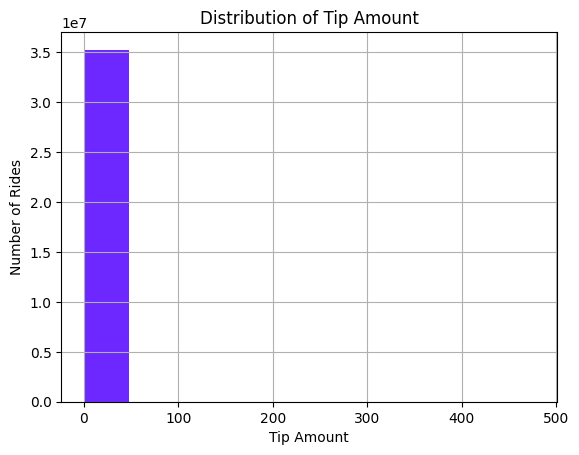

In [71]:
# Look at the distribution of tip_amount
df["tip_amount"].hist(color='#6c28ff')
plt.title('Distribution of Tip Amount')
plt.ylabel('Number of Rides')
plt.xlabel('Tip Amount')
plt.show()

In [72]:
# Look at how many tips are 0 vs >0
tip_zero = (df["tip_amount"] == 0).sum() # No tip given
tip_non_zero = (df["tip_amount"] > 0).sum() # Tip given
tip_below_zero = (df["tip_amount"] < 0).sum() # (Check for eg refunds, data errors)

print("Tip is 0:", tip_zero, f"({tip_zero/len(df)*100:.2f}%)")
print("Tip > 0:", tip_non_zero, f"({tip_non_zero/len(df)*100:.2f}%)")
print("Tip < 0:", tip_below_zero)

Tip is 0: 8915570 (25.28%)
Tip > 0: 26345720 (74.72%)
Tip < 0: 0


## 5. Fare-Related Attribute - fare_profit

`fare_profit` = `fare_amount` + `tips`

**Why?**
- `fare_amount` represents the time/distance number displayed by the taxi meter
- `total_amount` is the `fare_amount` + any surcharges and tolls + tips
- surcharges and tolls are not pocketed by the driver, they are paid back to eg NYC state
- tips are pocketed by the driver, and should be counted in a profit model

In [73]:
df["fare_profit"] = df["fare_amount"] + df["tip_amount"]

## 6. Temporal Aggregation — From Trip-Level to Hourly Demand

A key design decision in this pipeline is the **aggregation of individual trip
records into hourly demand counts per zone**. This transforms the problem from
a raw transaction log into a structured time-series forecasting task.

**Why aggregate?**
- Each row currently represents one taxi trip — not directly useful for demand
  forecasting
- We need to predict *"how many rides will happen in zone X during hour Y?"*
- Aggregating collapses ~35M rows into ~500K structured observations

**For each (zone, hour) pair we compute:**
- `demand` — count of pickups (demand team's **primary prediction target**)
- `avg_fare` — mean fare amount (fare team)
- `total_profit` — sum of calculated fare profits (fare team)
- `total_revenue` — sum of total amounts (fare team)

This aggregated data is also saved to `data/hourly_aggregated.csv` for use by
the revenue modelling team (Emma & Lucy), avoiding duplication of preprocessing work.

In [93]:
# Round each pickup timestamp down to the nearest hour
# e.g. 14:37 becomes 14:00 — this is our grouping key
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

# Group by (zone, hour) and aggregate:
# - demand = count of trips (demand-side target variable)
# - avg_fare = mean fare per ride (fare-side target variable)
# - total_profit = total profit in that zone/hour (fare-side additional target variable if needbe)
# we use fare_amount for avg_fare and total_revenue to exclude charges not taken as profit by business (tolls & surcharges)
hourly = df.groupby(["pickup_hour", "PULocationID"]).agg(
    demand        = ("PULocationID", "count"),   # number of rides = demand
    avg_fare      = ("fare_amount", "mean"),      # average fare per ride
    avg_profit  = ("fare_profit", "mean"),        # average profit per ride
    total_revenue = ("total_amount", "sum")       # total revenue in zone/hour - FOR ILLUSTRATIVE PURPOSES ONLY
).reset_index()

print("Shape of aggregated data:", hourly.shape)
print("\nSample rows:")
hourly.head(5)

Shape of aggregated data: (507575, 6)

Sample rows:


,pickup_hour,PULocationID,demand,avg_fare,avg_profit,total_revenue
0,2002-12-31 22:00:00,50,1,10.0,13.00,18.00
1,2002-12-31 22:00:00,170,2,19.8,23.61,56.22
2,2002-12-31 22:00:00,237,1,7.9,7.90,11.90
3,2002-12-31 22:00:00,246,1,7.2,7.20,11.20
4,2002-12-31 23:00:00,162,1,45.7,57.53,70.97


In [52]:
# Finding the outlier and removing it (assuming a data error due to unusually large fare)
hourly.loc[hourly["total_profit"].idxmax()]

pickup_hour      2024-11-01 16:00:00
PULocationID                     237
demand                           436
avg_fare                  783.446101
total_profit               342889.66
total_revenue              345705.98
Name: 423640, dtype: object

In [53]:
subset = df[
    (df["pickup_hour"] == "2024-11-01 16:00:00") &
    (df["PULocationID"] == 237)
]

subset[["fare_amount", "tip_amount", "total_amount"]].describe()

,fare_amount,tip_amount,total_amount
count,436.000000,436.000000,436.000000
mean,783.446101,2.998073,792.903624
std,16069.002417,3.039265,16068.862406
min,3.700000,0.000000,10.200000
25%,8.600000,1.000000,16.447500
50%,11.400000,2.880000,20.560000
75%,17.000000,4.105000,26.932500
max,335544.440000,38.400000,335550.940000


In [ ]:
subset.sort_values("fare_amount", ascending=False).head(3)

# Looks like it's just the one outlier - likely a data error

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour,has_tip,fare_profit
33921583,1,2024-11-01 16:15:08,2024-11-01 16:30:32,1.0,2.0,1.0,N,237,239,3,...,0.5,0.0,0.00,1.0,335550.94,2.5,0.0,2024-11-01 16:00:00,False,335544.44
33923568,1,2024-11-01 16:26:30,2024-11-01 17:47:57,1.0,18.5,3.0,N,237,1,1,...,0.0,38.4,20.00,1.0,166.40,0.0,0.0,2024-11-01 16:00:00,True,145.40
33921896,2,2024-11-01 16:06:23,2024-11-01 17:10:44,1.0,18.3,3.0,N,237,1,1,...,0.0,2.0,21.38,1.0,128.28,0.0,0.0,2024-11-01 16:00:00,True,103.40


## 7. Feature Engineering

Raw datetime objects cannot be directly consumed by machine learning models.
We extract a set of **meaningful temporal features** that capture known patterns
in urban taxi demand:

| Feature | Description | Why it matters |
|---|---|---|
| `hour` | Hour of day (0–23) | Captures rush hour vs quiet periods |
| `day_of_week` | Day of week (0=Mon, 6=Sun) | Captures weekday vs weekend patterns |
| `month` | Month of year (1–12) | Captures seasonal variation |
| `is_weekend` | Binary flag (1=Sat/Sun) | Separates commuter vs leisure demand |

### Lag Features
We also engineer **lag features** — a standard technique in time-series forecasting
that provides the model with recent historical context:

| Feature | Description |
|---|---|
| `demand_lag_1h` | Demand 1 hour ago in the same zone |
| `demand_lag_24h` | Demand at the same hour yesterday |
| `demand_lag_168h` | Demand at the same hour last week |

Lag features are typically the most powerful predictors in demand forecasting —
if a zone is busy now, it is likely to remain busy in the near future.

Rows with NaN lag values (the initial observations per zone, before enough history
exists) are dropped to ensure model training uses complete feature vectors.

In [104]:
# Sort by zone and time — required for lag features to work correctly
hourly = hourly.sort_values(["PULocationID", "pickup_hour"]).reset_index(drop=True)

# Extract basic time features from the pickup hour timestamp
hourly["hour"]        = hourly["pickup_hour"].dt.hour         # 0-23: captures intra-day patterns
hourly["day_of_week"] = hourly["pickup_hour"].dt.dayofweek    # 0=Monday, 6=Sunday
hourly["month"]       = hourly["pickup_hour"].dt.month        # 1-12: captures seasonal patterns
hourly["is_weekend"]  = hourly["day_of_week"].isin([5, 6]).astype(int)  # 1 if Saturday or Sunday

# Lag features: demand in the same zone at previous time points
# These are computed per zone (groupby PULocationID) to avoid leaking info across zones
hourly["demand_lag_1h"]   = hourly.groupby("PULocationID")["demand"].shift(1)    # 1 hour ago
hourly["demand_lag_24h"]  = hourly.groupby("PULocationID")["demand"].shift(24)   # same hour yesterday
hourly["demand_lag_168h"] = hourly.groupby("PULocationID")["demand"].shift(168)  # same hour last week

# Drop rows where lag features are NaN
# (the first 168 hours per zone won't have a full week of history)
hourly = hourly.dropna()

print("Shape after feature engineering:", hourly.shape)
print("\nFeature preview (first 3 rows):")
hourly.head(3)

Shape after feature engineering: (496483, 13)

Feature preview (first 3 rows):


,pickup_hour,PULocationID,demand,avg_fare,avg_profit,total_revenue,hour,day_of_week,month,is_weekend,demand_lag_1h,demand_lag_24h,demand_lag_168h
168,2024-01-10 09:00:00,4,5,18.112,20.606,120.53,9,2,1,0,4.0,3.0,22.0
169,2024-01-10 10:00:00,4,2,19.285,23.940,55.88,10,2,1,0,5.0,4.0,26.0
170,2024-01-10 11:00:00,4,5,18.400,20.730,121.15,11,2,1,0,2.0,1.0,31.0


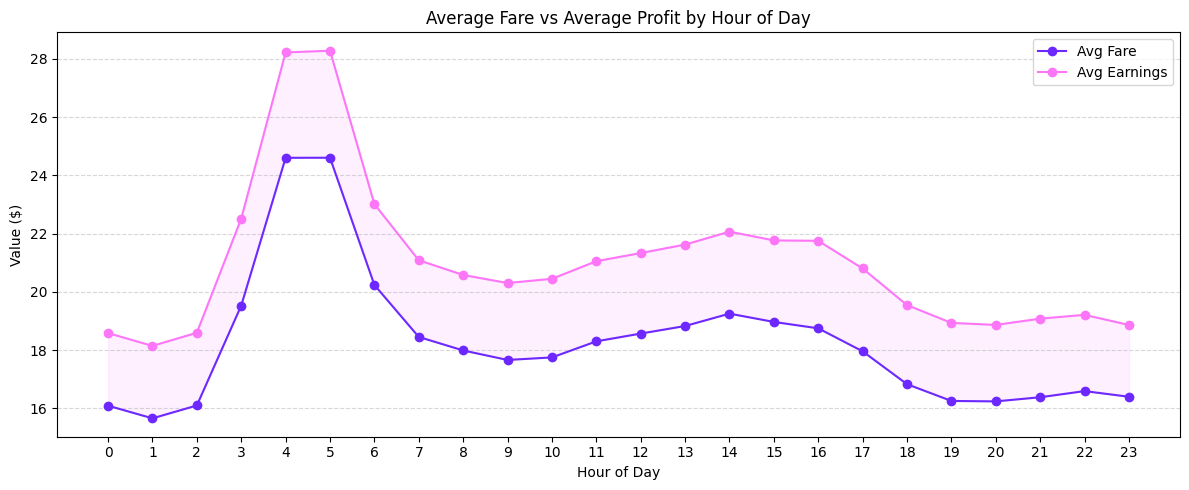

In [114]:
pretty_palette = ['#6c28ff','#fc76f7', "#fab4ff"]

hourly_avg_fare = hourly.groupby("hour")["avg_fare"].mean().reset_index()
hourly_avg_profit = hourly.groupby("hour")["avg_profit"].mean().reset_index()

plt.figure(figsize=(12,5))

plt.plot(hourly_avg_fare["hour"], hourly_avg_fare["avg_fare"], marker="o", label="Avg Fare", color="#6c28ff")
plt.plot(hourly_avg_profit["hour"], hourly_avg_profit["avg_profit"], marker="o", label="Avg Earnings", color="#fc76f7")

# Shade between two lines
plt.fill_between(
    hourly_avg_fare["hour"],
    hourly_avg_fare["avg_fare"],
    hourly_avg_profit["avg_profit"],
    color=pretty_palette[2],
    alpha=0.2
)

plt.title("Average Fare vs Average Profit by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Value ($)")
plt.xticks(range(0,24))
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()